In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("Housing.csv")
print("Dataset loaded successfully")
df.head(10)

Dataset loaded successfully


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Observation

The dataset contains information about houses including area, bedrooms, bathrooms, stories, parking facilities, furnishing status, and other features that may influence house prices.

In [33]:
print("Rows and Columns:", df.shape)
df.info()

Rows and Columns: (545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


## Dataset Overview

The dataset contains **545 rows** and **13 columns**.

### Target Variable

The target variable is:

- **price**

This is the variable that the machine learning model will predict.

### Feature Variables

The following variables are used as input features:

- area
- bedrooms
- bathrooms
- stories
- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- parking
- prefarea
- furnishingstatus

In [38]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [34]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [37]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


mainroad
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

basement
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus
<ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


C:\Users\risha\AppData\Local\Temp\ipykernel_17160\1091807614.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## Task 2 - Data Cleaning

### Missing Value Analysis

All columns contain 545 non-null values. Therefore, no missing values are present in the dataset and no imputation was required.

### Duplicate Row Analysis

The dataset contains **0 duplicate rows**. Therefore, no duplicate removal was required.

### Categorical Feature Analysis

The following categorical columns were identified:

- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea
- furnishingstatus

Analysis of unique values showed that:

- `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, and `prefarea` contain binary categories (`yes` / `no`).
- `furnishingstatus` contains three categories:
  - furnished
  - semi-furnished
  - unfurnished

### Encoding Strategy

Since machine learning models require numerical input, all categorical variables will be converted into numerical form using **One-Hot Encoding**.

This transformation creates separate binary columns for each category while preserving the information contained in the original categorical features.

### One-Hot Encoding

Machine learning models cannot directly process categorical text values such as
"yes", "no", or furnishing categories.

Therefore, One-Hot Encoding is applied to convert all categorical variables into
numerical binary columns.

In [39]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [44]:
bool_columns = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


### Encoding of Categorical Variables

All categorical variables were converted into numerical format using One-Hot Encoding.

Binary categorical variables such as `mainroad`, `guestroom`, and `airconditioning` were transformed into binary indicator columns.

The `furnishingstatus` feature was expanded into separate binary columns representing its categories.

After encoding, all features in the dataset were represented numerically and became suitable for machine learning algorithms.

In [46]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]
print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (436, 13)
Testing Set: (109, 13)


## Task 3 - Model Building

### Linear Regression Model

A Linear Regression model is trained to learn the relationship between house features and house prices.

The model uses the training dataset and is evaluated on the testing dataset.

In [50]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 235.97, 76778.7 ,1094444.79,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea_yes', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [51]:
y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr[:5])

[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


In [52]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(
    y_test,
    y_pred_lr
) ** 0.5

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

MAE : 970043.4039201637
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


### Linear Regression Results

The Linear Regression model achieved:

- MAE = 970,043
- RMSE = 1,324,507
- R² Score = 0.653

The model explains approximately 65.3% of the variation in house prices. While the model captures important relationships between housing features and price, there is still room for improvement.

In [53]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [55]:
y_pred_rf = rf_model.predict(X_test)
print(y_pred_rf[:5])

[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [56]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


### Model Comparison

Both Linear Regression and Random Forest Regressor models were trained and evaluated.

| Metric | Linear Regression | Random Forest |
|----------|----------|----------|
| MAE | 970,043 | 1,021,546 |
| RMSE | 1,324,507 | 1,400,566 |
| R² Score | 0.653 | 0.612 |

The Linear Regression model outperformed the Random Forest Regressor on all evaluation metrics. Therefore, Linear Regression was selected as the better-performing model for this dataset.

## Task 4- Charts
### Chart 1: Distribution of House Prices

A histogram is used to visualize the distribution of house prices in the dataset.

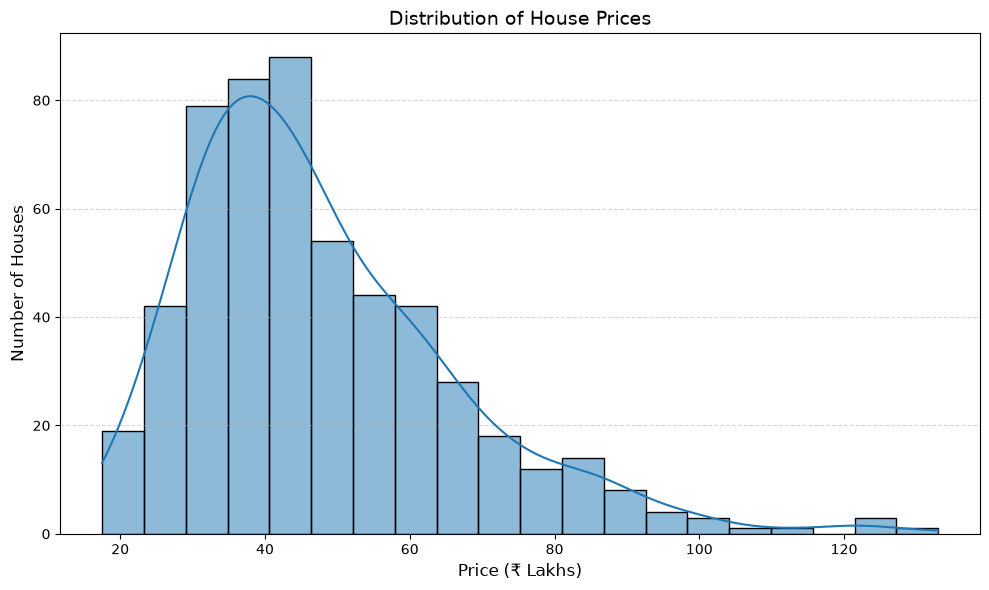

In [61]:
plt.figure(figsize=(10, 6))

price_lakh = df["price"] / 100000

sns.histplot(
    price_lakh,
    bins=20,
    kde=True
)

plt.title("Distribution of House Prices", fontsize=14)
plt.xlabel("Price (₹ Lakhs)", fontsize=12)
plt.ylabel("Number of Houses", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("charts/price_histogram.png", dpi=300)
plt.show()

### Observation

The distribution of house prices is positively skewed. Most properties are concentrated in the lower and middle price ranges, while a small number of high-value houses create a long tail on the right side of the distribution.

## Chart 2: Correlation Heatmap

### Overview

A correlation heatmap is used to visualize the relationships between different housing features and house prices.

Correlation values range from -1 to +1:

- **+1** indicates a strong positive relationship.
- **0** indicates no relationship.
- **-1** indicates a strong negative relationship.

This visualization helps identify which features have the greatest influence on house prices and provides insights into the overall structure of the dataset.

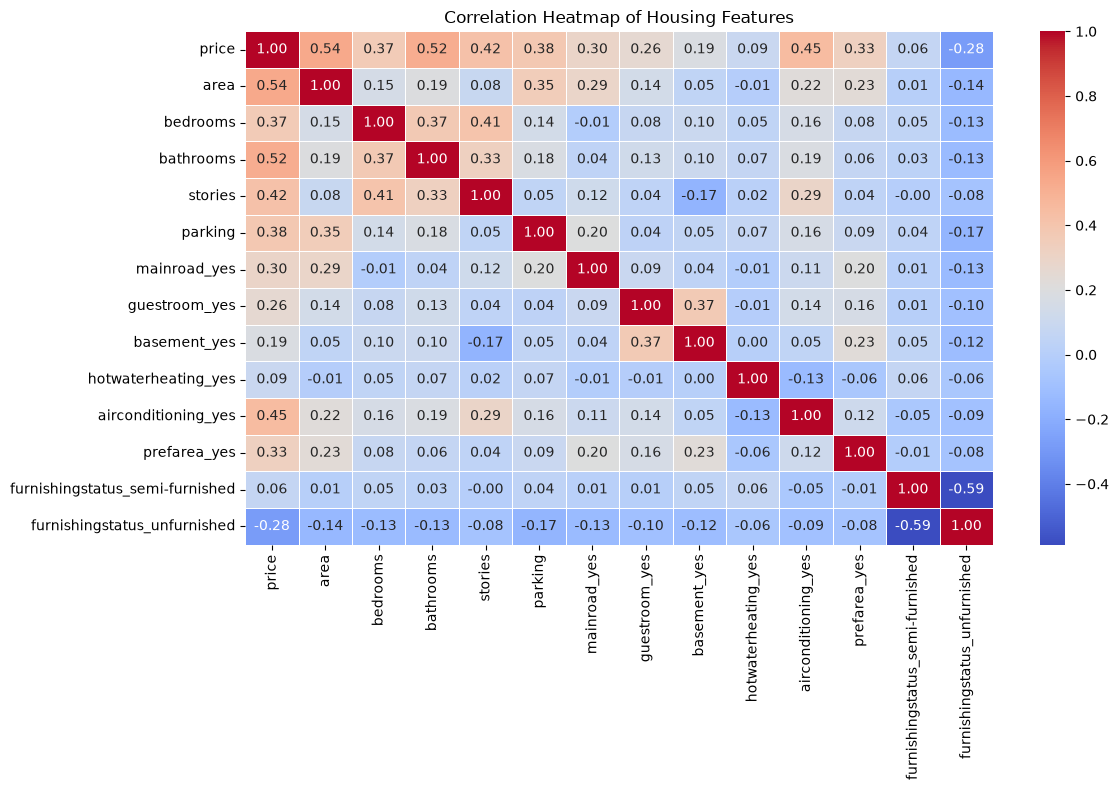

In [62]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_encoded.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Housing Features")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=300)
plt.show()

### Observation

The heatmap indicates that features such as area, bathrooms, stories, and air conditioning have positive correlations with house price.

Among all features, area is expected to have one of the strongest relationships with price, suggesting that larger houses generally command higher prices.

The heatmap also reveals weaker relationships for some features, indicating that they contribute less to price prediction compared to highly correlated variables.

## Chart 3: Actual vs Predicted House Prices

### Overview

This scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

The purpose of this visualization is to evaluate the model's predictive performance. A perfect model would place all data points exactly on the reference line where the actual price equals the predicted price.

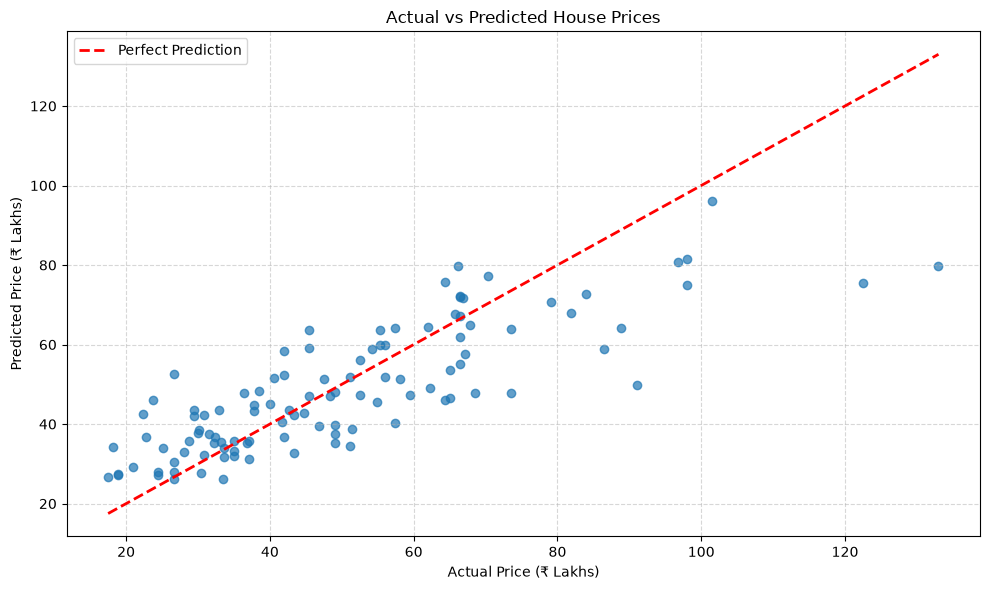

In [64]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test / 100000,
    y_pred_lr / 100000,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_lr.min()) / 100000
max_price = max(y_test.max(), y_pred_lr.max()) / 100000

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price (₹ Lakhs)")
plt.ylabel("Predicted Price (₹ Lakhs)")
plt.legend()

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("charts/actual_vs_predicted.png", dpi=300)
plt.show()

### Observation

The scatter plot shows a clear positive relationship between actual and predicted house prices, indicating that the Linear Regression model successfully captures the overall pricing trend.

Most data points are located reasonably close to the reference line, which suggests that the model produces fairly accurate predictions for the majority of houses.

However, the spread of points increases for higher-priced properties. The model tends to underestimate some premium houses, as seen from several points lying significantly below the reference line at higher price ranges.

This observation is consistent with the model's evaluation metrics (R² = 0.653), indicating moderate predictive performance with some room for improvement.

## Task 5 – Insights & Summary

The analysis showed that **area, number of bathrooms, air conditioning, and number of stories** were among the most influential factors affecting house prices. Larger houses with more amenities generally tended to have higher market values. The Linear Regression model achieved an **R² score of 0.653**, meaning it was able to explain approximately **65.3% of the variation in house prices**, which indicates moderate predictive accuracy. One intriguing finding was that the dataset exhibited a strongly right-skewed price distribution. Most houses were concentrated in the ₹30–₹60 lakh range, while a small number of premium properties extended beyond ₹1 crore. These high-value properties contribute disproportionately to the overall price variation and make accurate prediction more challenging. Based on these findings, a real estate business should focus on highlighting property size, bathroom count, and premium amenities such as air conditioning when marketing homes, as these features appear to have the strongest influence on pricing.
